## Section 1: Imports & Config

In [39]:
import subprocess, sys
for pkg in ['pandas', 'numpy', 'matplotlib', 'seaborn', 'scipy',
            'scikit-learn', 'xgboost', 'lightgbm', 'catboost', 'shap',
            'joblib', 'optuna', 'imbalanced-learn']:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', pkg])

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats

from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (roc_auc_score, average_precision_score, f1_score,
                             roc_curve, precision_recall_curve, classification_report,
                             confusion_matrix)
from sklearn.calibration import CalibratedClassifierCV
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import RFECV

import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostClassifier, Pool
import shap
import joblib
import os, warnings
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)
warnings.filterwarnings('ignore')

# Global config
SEED = 42
N_FOLDS = 5
N_OPTUNA_TRIALS = 60  # tuning trials per model
np.random.seed(SEED)

sns.set_style('whitegrid')
plt.rcParams.update({
    'figure.dpi': 150,
    'savefig.dpi': 150,
    'font.size': 10,
    'axes.titlesize': 12,
    'axes.labelsize': 10
})
PALETTE = sns.color_palette('Set2')
DEFAULT_COLORS = {0: PALETTE[0], 1: PALETTE[1]}

for d in ['outputs/plots', 'outputs/shap', 'outputs/predictions', 'outputs/model']:
    os.makedirs(d, exist_ok=True)

print('✅ All imports and config done.')

✅ All imports and config done.


## Section 2: Data Loading & Quality Audit

In [40]:
df_train = pd.read_csv('/content/loan_train.csv', parse_dates=['application_date'])
df_test  = pd.read_csv('/content/loan_test.csv',  parse_dates=['application_date'])

TEST_HAS_TARGET = 'default_flag' in df_test.columns
print(f'Train shape: {df_train.shape}')
print(f'Test shape:  {df_test.shape}')
print(f'Test has default_flag: {TEST_HAS_TARGET}')

# Basic audit
for label, df in [('TRAIN', df_train), ('TEST', df_test)]:
    print(f"\n{'='*60}")
    print(f"  {label} — Shape: {df.shape}")
    print(f"{'='*60}")
    nulls = df.isnull().sum()
    null_df = pd.DataFrame({'count': nulls, 'pct': (nulls/len(df)*100).round(2)})
    print(null_df[null_df['count'] > 0].to_string() if null_df['count'].sum() > 0 else '  No nulls found.')
    dups = df['loan_id'].duplicated().sum()
    print(f'  Duplicate loan_ids: {dups}')
    if dups > 0:
        df.drop_duplicates(subset='loan_id', inplace=True)

# Class balance
vc = df_train['default_flag'].value_counts().sort_index()
pct = (vc / len(df_train) * 100).round(2)
print(f'\n--- Class Balance ---')
for v in vc.index:
    print(f'  Class {v}: {vc[v]:>5d} ({pct[v]:.2f}%)')

print('\n✅ Data loaded.')

Train shape: (8000, 24)
Test shape:  (2500, 23)
Test has default_flag: False

  TRAIN — Shape: (8000, 24)
           count    pct
ltv_ratio   6583  82.29
  Duplicate loan_ids: 0

  TEST — Shape: (2500, 23)
           count    pct
ltv_ratio   2069  82.76
  Duplicate loan_ids: 0

--- Class Balance ---
  Class 0:  5772 (72.15%)
  Class 1:  2228 (27.85%)

✅ Data loaded.


## Section 3: EDA (condensed — full EDA done in iter1)

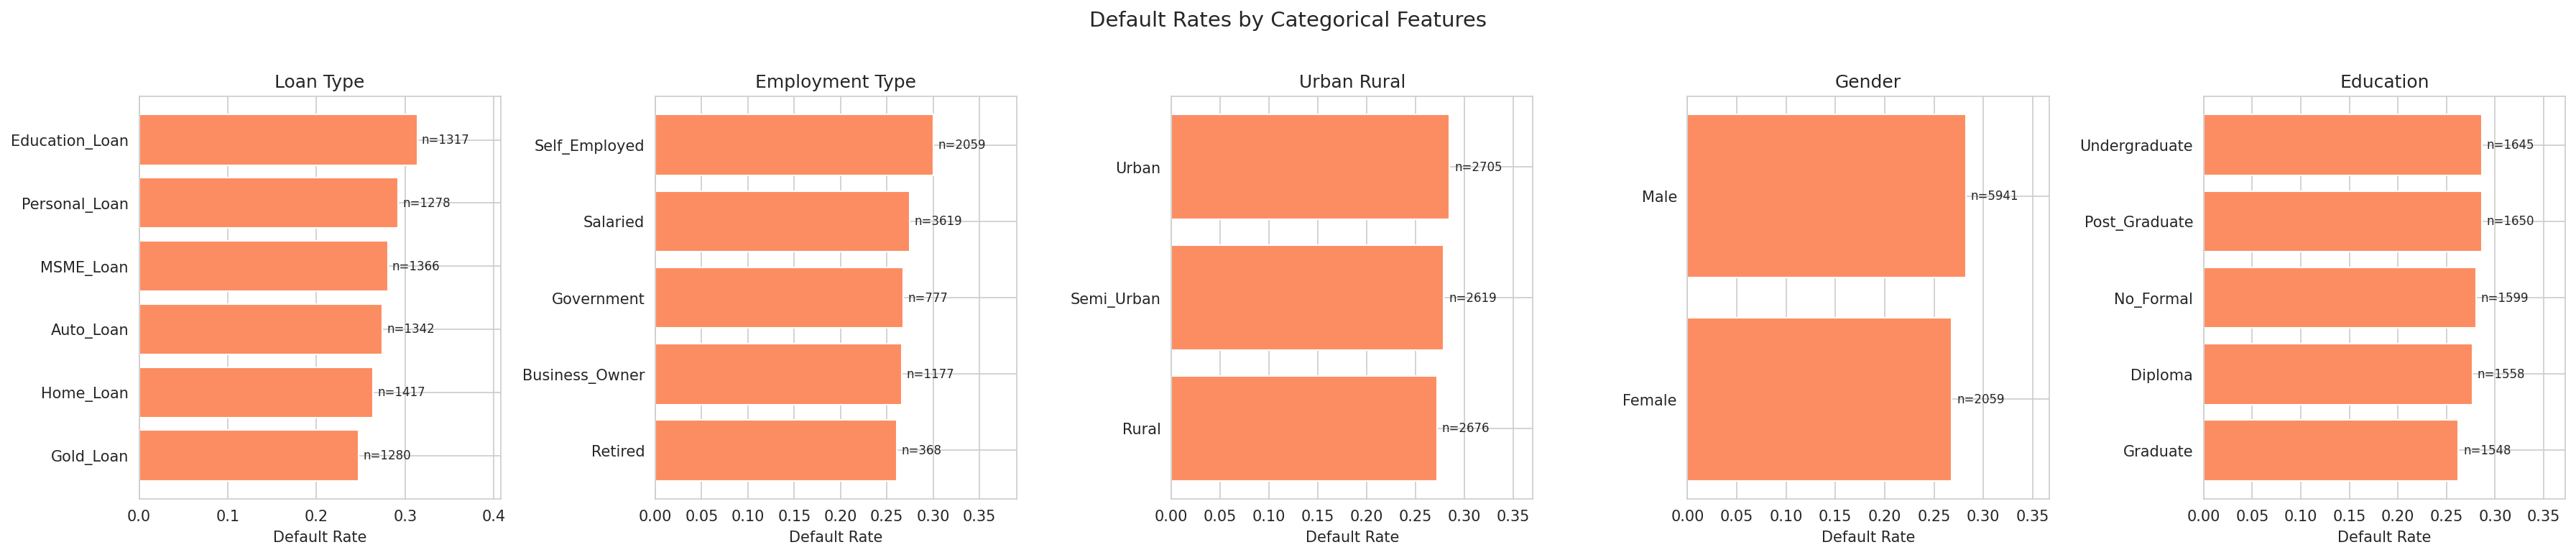

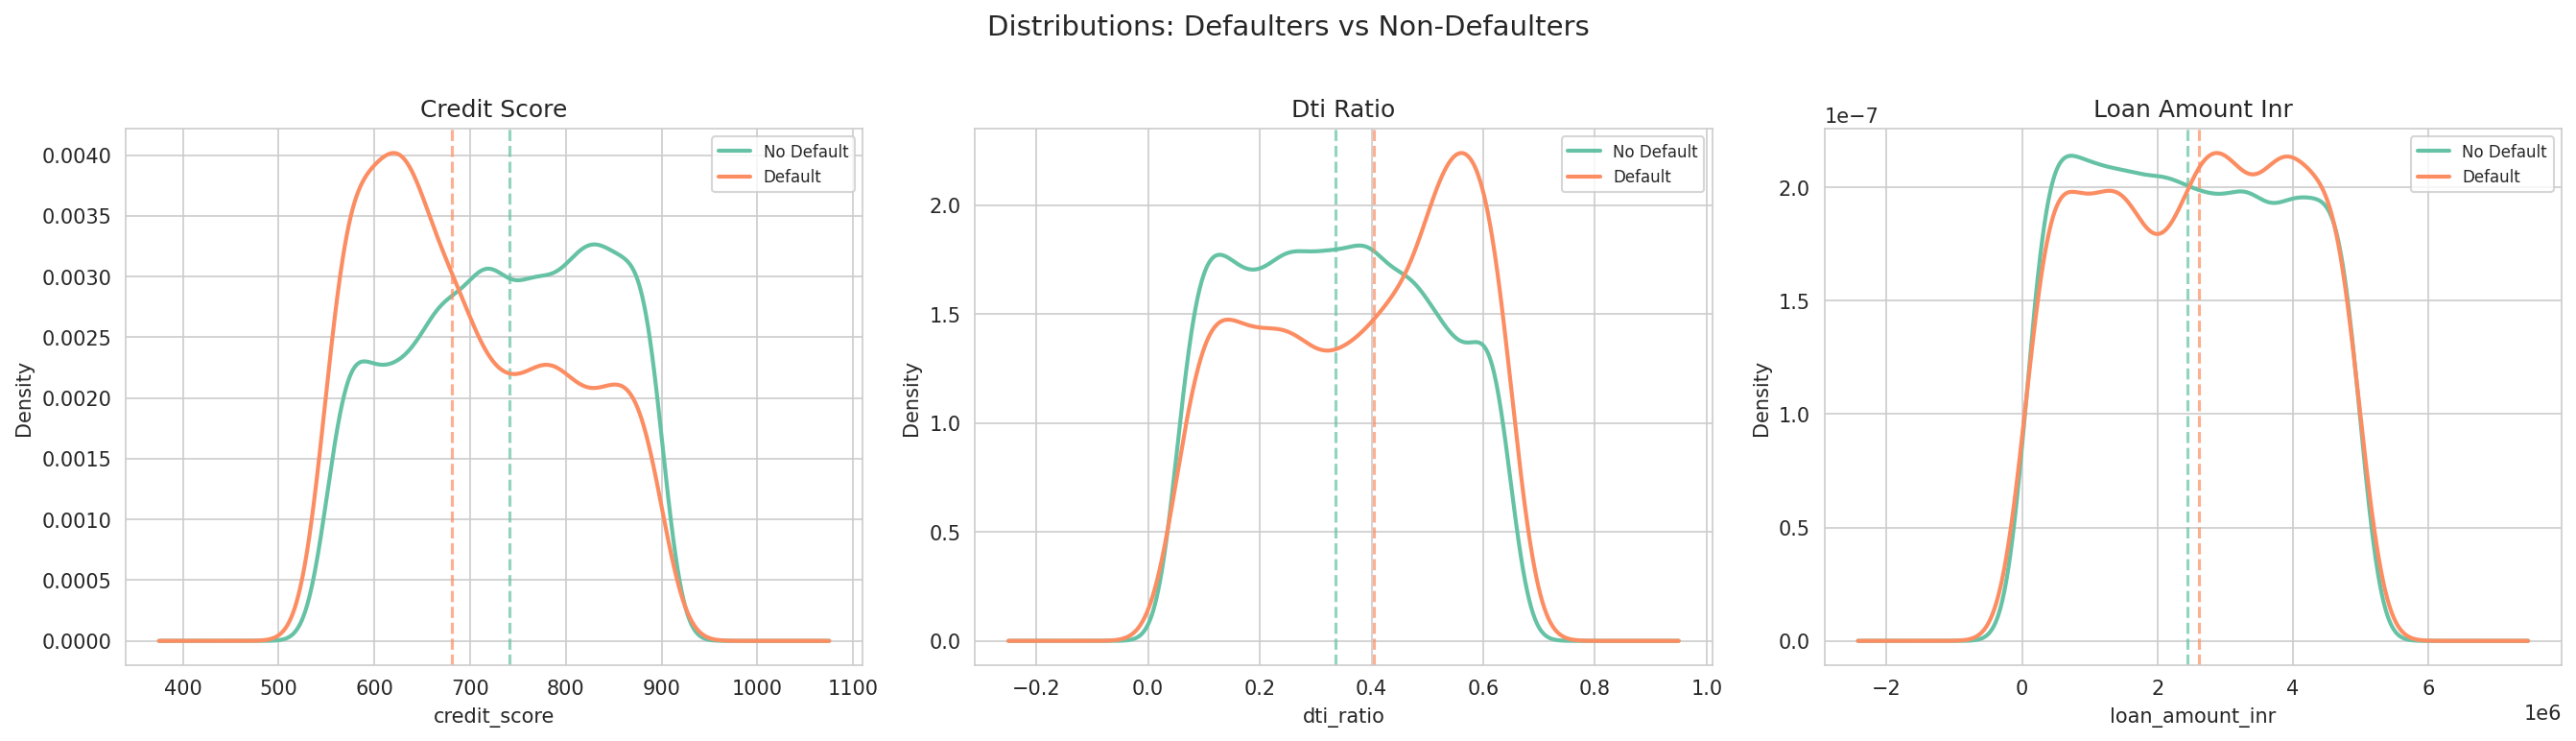

✅ EDA plots done.


In [41]:
# 3.1 Default rates by category
cat_eda_cols = ['loan_type', 'employment_type', 'urban_rural', 'gender', 'education']
fig, axes = plt.subplots(1, 5, figsize=(24, 5))
for i, col in enumerate(cat_eda_cols):
    ax = axes[i]
    grp = df_train.groupby(col)['default_flag'].agg(['mean', 'count']).reset_index()
    grp.columns = [col, 'default_rate', 'count']
    grp = grp.sort_values('default_rate', ascending=True)
    bars = ax.barh(grp[col], grp['default_rate'], color=PALETTE[1], edgecolor='white')
    for bar, cnt in zip(bars, grp['count']):
        ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
                f'n={cnt}', va='center', fontsize=8)
    ax.set_xlabel('Default Rate')
    ax.set_title(col.replace('_', ' ').title())
    ax.set_xlim(0, grp['default_rate'].max() * 1.3)
plt.suptitle('Default Rates by Categorical Features', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('outputs/plots/3_1_default_by_category.png', bbox_inches='tight')
plt.show()

# 3.2 Continuous distributions
cont_cols = ['credit_score', 'dti_ratio', 'loan_amount_inr']
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, col in enumerate(cont_cols):
    ax = axes[i]
    for flag, label, color in [(0, 'No Default', PALETTE[0]), (1, 'Default', PALETTE[1])]:
        subset = df_train[df_train['default_flag'] == flag][col].dropna()
        subset.plot.kde(ax=ax, label=label, color=color, lw=2)
        med = subset.median()
        ax.axvline(med, color=color, linestyle='--', alpha=0.7)
    if col == 'loan_amount_inr' and df_train[col].skew() > 2:
        ax.set_xscale('log')
        ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e5:.0f}L'))
    ax.set_title(col.replace('_', ' ').title())
    ax.set_xlabel(col)
    ax.legend(fontsize=8)
plt.suptitle('Distributions: Defaulters vs Non-Defaulters', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('outputs/plots/3_2_continuous_distributions.png', bbox_inches='tight')
plt.show()
print('✅ EDA plots done.')

## Section 4: Feature Engineering — Improved

**Iter2 changes:**
- Dropped redundant correlated features (r > 0.98)
- Fixed EMI formula edge cases, added log-transform
- Added log1p on behavioral features (missed_payments, bureau_enquiries)
- Added explicit interaction: missed_payments × dti
- Added rank-based features for extreme values

In [42]:
# 4.1 Outlier capping — compute on train only
cap_cols = ['annual_income_inr', 'loan_amount_inr', 'savings_account_balance_inr']
cap_values = {}
for col in cap_cols:
    lo = df_train[col].quantile(0.01)
    hi = df_train[col].quantile(0.99)
    cap_values[col] = (lo, hi)
    print(f'Cap {col}: [{lo:.0f}, {hi:.0f}]')

for df in [df_train, df_test]:
    for col, (lo, hi) in cap_values.items():
        df[col] = df[col].clip(lo, hi)

print(f'\nTrain shape after capping: {df_train.shape}')
print(f'Test shape after capping:  {df_test.shape}')

Cap annual_income_inr: [279065, 2975038]
Cap loan_amount_inr: [91599, 4944933]
Cap savings_account_balance_inr: [4620, 494884]

Train shape after capping: (8000, 24)
Test shape after capping:  (2500, 23)


In [43]:
# 4.2 LTV handling
for df in [df_train, df_test]:
    df['ltv_is_missing'] = df['ltv_ratio'].isnull().astype(int)
    df['ltv_ratio'] = df['ltv_ratio'].fillna(-1)
print('LTV handling done.')

LTV handling done.


In [44]:
# 4.3 Required features
for df in [df_train, df_test]:
    df['loan_to_income_ratio']    = df['loan_amount_inr'] / (df['annual_income_inr'] + 1)
    df['dti_credit_risk']         = df['dti_ratio'] / (df['credit_score'] / 700)
    df['income_per_year_employed'] = df['annual_income_inr'] / (df['employment_years'] + 1)
print('Required features created.')

Required features created.


In [45]:
# 4.4 Temporal features
earliest_date = df_train['application_date'].min()
for df in [df_train, df_test]:
    df['app_month']         = df['application_date'].dt.month
    df['app_quarter']       = df['application_date'].dt.quarter
    df['app_day_of_week']   = df['application_date'].dt.dayofweek
    df['days_since_earliest'] = (df['application_date'] - earliest_date).dt.days
    df.drop(columns='application_date', inplace=True)
print('Temporal features created. application_date dropped.')

Temporal features created. application_date dropped.


In [46]:
# 4.5 Advanced domain features — IMPROVED
def create_advanced_features(df, interest_rate_medians=None, fit=False):
    """All advanced features. fit=True computes medians from this df."""

    # --- EMI calculation (fixed: handle r=0, clip extremes) ---
    P = df['loan_amount_inr']
    r = (df['interest_rate_pct'] / 100 / 12).clip(lower=1e-9)  # monthly rate, no zeros
    n = df['loan_tenure_months'].clip(lower=1)
    compound = (1 + r) ** n
    emi = P * r * compound / (compound - 1)
    emi = emi.fillna(0).clip(lower=0)

    monthly_income = df['annual_income_inr'] / 12
    df['emi_to_income_ratio']  = emi / (monthly_income + 1)
    df['log_emi_to_income']    = np.log1p(df['emi_to_income_ratio'])   # NEW: log-transform
    df['total_debt_exposure']  = df['loan_amount_inr'] * (1 + df['dti_ratio'])
    df['savings_to_loan_ratio'] = df['savings_account_balance_inr'] / (df['loan_amount_inr'] + 1)
    df['savings_to_emi_ratio']  = df['savings_account_balance_inr'] / (emi + 1)

    # --- Behavioral risk (log-transformed — heavily right-skewed) ---
    df['missed_payment_rate']     = df['missed_payments_2y'] / (df['num_existing_loans'] + 1)
    df['enquiry_intensity']       = df['bureau_enquiries_6m'] / (df['num_existing_loans'] + 1)
    df['credit_utilization_proxy'] = df['num_existing_loans'] * df['dti_ratio']
    df['log_missed_payments']     = np.log1p(df['missed_payments_2y'])      # NEW
    df['log_bureau_enquiries']    = np.log1p(df['bureau_enquiries_6m'])      # NEW

    # --- Credit profile ---
    # NOTE: drop credit_score_squared — r=0.998 with credit_score (iter1 finding)
    df['credit_score_x_dti']  = df['credit_score'] * df['dti_ratio']
    df['low_credit_flag']     = (df['credit_score'] < 650).astype(int)
    df['high_dti_flag']       = (df['dti_ratio'] > 0.45).astype(int)
    df['high_risk_combo']     = ((df['low_credit_flag'] == 1) & (df['high_dti_flag'] == 1)).astype(int)

    # NEW: Interaction — missed payments × dti (both high = very risky)
    df['missed_x_dti']        = df['missed_payments_2y'] * df['dti_ratio']
    # NEW: Missed payments × low credit flag
    df['missed_x_low_credit'] = df['missed_payments_2y'] * df['low_credit_flag']
    # NEW: Savings cover in months (how long savings can cover EMI)
    df['months_savings_cover'] = (df['savings_account_balance_inr'] / (emi + 1)).clip(upper=120)

    # --- Loan characteristics ---
    # NOTE: drop tenure_years — r=1.0 with loan_tenure_months (iter1 finding)
    # NOTE: interest_rate_pct kept, interest_spread kept but we drop interest_spread below if r>0.99
    if fit:
        interest_rate_medians = df.groupby('loan_type')['interest_rate_pct'].median().to_dict()
    df['interest_spread'] = df.apply(
        lambda row: row['interest_rate_pct'] - interest_rate_medians.get(row['loan_type'], 0), axis=1)
    # NOTE: don't add total_repayment — highly correlated with loan_amount

    if fit:
        return interest_rate_medians
    return None

ir_medians = create_advanced_features(df_train, fit=True)
create_advanced_features(df_test, interest_rate_medians=ir_medians, fit=False)

print('Advanced domain features created.')
print(f'Train shape: {df_train.shape}')
print(f'Test shape:  {df_test.shape}')

Advanced domain features created.
Train shape: (8000, 49)
Test shape:  (2500, 48)


In [47]:
# 4.6 Categorical encoding
target_encode_cols = ['state', 'loan_purpose']
SMOOTHING = 10
global_default_mean = df_train['default_flag'].mean()
target_enc_maps = {}

skf_te = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)
for col in target_encode_cols:
    cat_means = df_train.groupby(col)['default_flag'].agg(['mean', 'count'])
    cat_means['smoothed'] = (cat_means['count'] * cat_means['mean'] + SMOOTHING * global_default_mean) / (cat_means['count'] + SMOOTHING)
    target_enc_maps[col] = cat_means['smoothed'].to_dict()
    df_train[col + '_te'] = np.nan
    for tr_idx, val_idx in skf_te.split(df_train, df_train['default_flag']):
        fold_means = df_train.iloc[tr_idx].groupby(col)['default_flag'].agg(['mean', 'count'])
        fold_means['smoothed'] = (fold_means['count'] * fold_means['mean'] + SMOOTHING * global_default_mean) / (fold_means['count'] + SMOOTHING)
        fold_map = fold_means['smoothed'].to_dict()
        df_train.loc[df_train.index[val_idx], col + '_te'] = df_train.iloc[val_idx][col].map(fold_map)
    df_train[col + '_te'] = df_train[col + '_te'].fillna(global_default_mean)
    df_test[col + '_te']  = df_test[col].map(target_enc_maps[col]).fillna(global_default_mean)

print('Target encoding done for:', target_encode_cols)

ohe_cols = ['gender', 'education', 'urban_rural', 'employment_type', 'loan_type']
ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore', drop='first')
ohe.fit(df_train[ohe_cols])
ohe_feature_names = ohe.get_feature_names_out(ohe_cols)
train_ohe = pd.DataFrame(ohe.transform(df_train[ohe_cols]), columns=ohe_feature_names, index=df_train.index)
test_ohe  = pd.DataFrame(ohe.transform(df_test[ohe_cols]),  columns=ohe_feature_names, index=df_test.index)
df_train = pd.concat([df_train, train_ohe], axis=1)
df_test  = pd.concat([df_test,  test_ohe],  axis=1)
print(f'One-hot features added: {len(ohe_feature_names)}')

# Drop columns — include redundant ones identified in iter1
drop_cols = ['loan_id'] + target_encode_cols + ohe_cols
# Drop redundant high-correlation features (iter1 finding: r > 0.98)
redundant_cols = [
    'tenure_years',          # r=1.00 with loan_tenure_months
    'credit_score_squared',  # r=0.998 with credit_score
    'total_repayment',       # r=0.969 with loan_amount_inr
    'total_debt_exposure',   # r=0.969 with loan_amount_inr
    # interest_spread has r=0.999 with interest_rate_pct — keep only spread
    'interest_rate_pct',     # keep interest_spread instead (more meaningful)
]
drop_cols = [c for c in drop_cols + redundant_cols if c in df_train.columns]
test_loan_ids = df_test['loan_id'].values if 'loan_id' in df_test.columns else None
df_train.drop(columns=drop_cols, inplace=True)
df_test.drop(columns=[c for c in drop_cols if c in df_test.columns], inplace=True)
print(f'Dropped: {drop_cols}')
print(f'Train shape: {df_train.shape}')
print(f'Test shape:  {df_test.shape}')

Target encoding done for: ['state', 'loan_purpose']
One-hot features added: 16
Dropped: ['loan_id', 'state', 'loan_purpose', 'gender', 'education', 'urban_rural', 'employment_type', 'loan_type', 'total_debt_exposure', 'interest_rate_pct']
Train shape: (8000, 57)
Test shape:  (2500, 56)


In [48]:
# 4.7 Feature scaling
y_train = df_train.pop('default_flag')
y_test  = df_test.pop('default_flag') if TEST_HAS_TARGET else None

feature_cols = df_train.columns.tolist()
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(df_train), columns=feature_cols, index=df_train.index)
X_test_scaled  = pd.DataFrame(scaler.transform(df_test),      columns=feature_cols, index=df_test.index)

print(f'Scaling done. Scaler fitted on {len(feature_cols)} features.')
print(f'X_train: {X_train_scaled.shape}, y_train: {y_train.shape}')
if y_test is not None:
    print(f'X_test:  {X_test_scaled.shape},  y_test:  {y_test.shape}')
else:
    print(f'X_test:  {X_test_scaled.shape},  y_test:  N/A')

print(f'\n{"="*60}')
print(f'  Final Feature Count: {len(feature_cols)}')
print(f'{"="*60}')
for i, col in enumerate(feature_cols, 1):
    print(f'  {i:3d}. {col}')

Scaling done. Scaler fitted on 56 features.
X_train: (8000, 56), y_train: (8000,)
X_test:  (2500, 56),  y_test:  N/A

  Final Feature Count: 56
    1. age
    2. employment_years
    3. annual_income_inr
    4. loan_amount_inr
    5. loan_tenure_months
    6. credit_score
    7. num_existing_loans
    8. dti_ratio
    9. ltv_ratio
   10. has_collateral
   11. bureau_enquiries_6m
   12. missed_payments_2y
   13. savings_account_balance_inr
   14. ltv_is_missing
   15. loan_to_income_ratio
   16. dti_credit_risk
   17. income_per_year_employed
   18. app_month
   19. app_quarter
   20. app_day_of_week
   21. days_since_earliest
   22. emi_to_income_ratio
   23. log_emi_to_income
   24. savings_to_loan_ratio
   25. savings_to_emi_ratio
   26. missed_payment_rate
   27. enquiry_intensity
   28. credit_utilization_proxy
   29. log_missed_payments
   30. log_bureau_enquiries
   31. credit_score_x_dti
   32. low_credit_flag
   33. high_dti_flag
   34. high_risk_combo
   35. missed_x_dti
   36

## Section 5: Post-Engineering Correlation Check

In [49]:
corr_eng = X_train_scaled.corr()

pairs_85 = []
for i in range(len(corr_eng)):
    for j in range(i+1, len(corr_eng)):
        r = corr_eng.iloc[i, j]
        if abs(r) > 0.85:
            pairs_85.append((corr_eng.index[i], corr_eng.columns[j], r))

print(f'--- Feature pairs with |r| > 0.85 (after redundancy removal) ---')
if pairs_85:
    for a, b, r in sorted(pairs_85, key=lambda x: -abs(x[2])):
        print(f'  {a} ↔ {b}: {r:.3f}')
else:
    print('  None found — good!')

# Point-biserial correlation with target
pb_corr = X_train_scaled.apply(lambda col: col.corr(y_train)).sort_values(ascending=False)
print('\n--- Top 15 features by correlation with default_flag ---')
print(pb_corr.head(15).to_string())
print('\n--- Bottom 10 (most negative) ---')
print(pb_corr.tail(10).to_string())

--- Feature pairs with |r| > 0.85 (after redundancy removal) ---
  ltv_is_missing ↔ loan_type_Home_Loan: -1.000
  ltv_ratio ↔ ltv_is_missing: -0.995
  ltv_ratio ↔ loan_type_Home_Loan: 0.995
  app_month ↔ app_quarter: 0.970
  missed_payments_2y ↔ log_missed_payments: 0.955
  bureau_enquiries_6m ↔ log_bureau_enquiries: 0.955
  dti_ratio ↔ credit_score_x_dti: 0.954
  dti_ratio ↔ dti_credit_risk: 0.952
  emi_to_income_ratio ↔ log_emi_to_income: 0.923
  savings_to_emi_ratio ↔ months_savings_cover: 0.899
  savings_to_loan_ratio ↔ months_savings_cover: 0.868
  savings_to_loan_ratio ↔ savings_to_emi_ratio: 0.866
  missed_payments_2y ↔ missed_x_dti: 0.860

--- Top 15 features by correlation with default_flag ---
missed_payments_2y          0.657394
log_missed_payments         0.649638
missed_x_dti                0.584768
missed_payment_rate         0.488551
missed_x_low_credit         0.413930
low_credit_flag             0.172235
dti_credit_risk             0.149086
high_risk_combo             

In [50]:
# 6.1 Setup
X = X_train_scaled.values
y = y_train.values

skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)

results = {}
oof_preds = {}

n_neg = (y == 0).sum()
n_pos = (y == 1).sum()
spw = n_neg / n_pos
print(f'Class balance — 0: {n_neg}, 1: {n_pos}, scale_pos_weight: {spw:.2f}')

Class balance — 0: 5772, 1: 2228, scale_pos_weight: 2.59


In [51]:
# 6.2 Model 1: Logistic Regression (baseline — same as iter1)
lr_aucs, lr_praucs, lr_f1s = [], [], []
oof_lr = np.zeros(len(y))

for fold, (tr_idx, val_idx) in enumerate(skf.split(X, y)):
    X_tr, X_val = X[tr_idx], X[val_idx]
    y_tr, y_val = y[tr_idx], y[val_idx]
    lr = LogisticRegression(C=0.1, penalty='l2', solver='lbfgs', max_iter=1000,
                            class_weight='balanced', random_state=SEED)
    lr.fit(X_tr, y_tr)
    proba = lr.predict_proba(X_val)[:, 1]
    oof_lr[val_idx] = proba
    lr_aucs.append(roc_auc_score(y_val, proba))
    lr_praucs.append(average_precision_score(y_val, proba))
    lr_f1s.append(f1_score(y_val, (proba >= 0.5).astype(int)))
    print(f'  Fold {fold+1}: ROC-AUC={lr_aucs[-1]:.4f}  PR-AUC={lr_praucs[-1]:.4f}  F1={lr_f1s[-1]:.4f}')

results['Logistic Regression'] = {
    'roc_auc': (np.mean(lr_aucs), np.std(lr_aucs)),
    'pr_auc':  (np.mean(lr_praucs), np.std(lr_praucs)),
    'f1':      (np.mean(lr_f1s), np.std(lr_f1s)),
}
oof_preds['Logistic Regression'] = oof_lr
print(f'\n  Mean: ROC-AUC={np.mean(lr_aucs):.4f}±{np.std(lr_aucs):.4f}')

  Fold 1: ROC-AUC=0.8801  PR-AUC=0.7947  F1=0.6941
  Fold 2: ROC-AUC=0.9179  PR-AUC=0.8563  F1=0.7395
  Fold 3: ROC-AUC=0.8979  PR-AUC=0.8324  F1=0.7280
  Fold 4: ROC-AUC=0.9016  PR-AUC=0.8420  F1=0.7219
  Fold 5: ROC-AUC=0.9077  PR-AUC=0.8306  F1=0.7237

  Mean: ROC-AUC=0.9010±0.0124


In [52]:
# 6.3 Optuna tuning for XGBoost
print('--- Optuna hyperparameter search for XGBoost ---')

def xgb_objective(trial):
    params = {
        'n_estimators':      trial.suggest_int('n_estimators', 300, 1500),
        'max_depth':         trial.suggest_int('max_depth', 3, 8),
        'learning_rate':     trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'subsample':         trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree':  trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'min_child_weight':  trial.suggest_int('min_child_weight', 1, 20),
        'gamma':             trial.suggest_float('gamma', 0, 5),
        'reg_alpha':         trial.suggest_float('reg_alpha', 1e-4, 10, log=True),
        'reg_lambda':        trial.suggest_float('reg_lambda', 1e-4, 10, log=True),
        'scale_pos_weight':  spw,
        'eval_metric':       'auc',
        'random_state':      SEED,
        'use_label_encoder': False,
        'verbosity':         0,
    }
    fold_aucs = []
    for tr_idx, val_idx in skf.split(X, y):
        m = xgb.XGBClassifier(**params, early_stopping_rounds=30)
        m.fit(X[tr_idx], y[tr_idx],
              eval_set=[(X[val_idx], y[val_idx])],
              verbose=False)
        proba = m.predict_proba(X[val_idx])[:, 1]
        fold_aucs.append(roc_auc_score(y[val_idx], proba))
    return np.mean(fold_aucs)

study_xgb = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=SEED))
study_xgb.optimize(xgb_objective, n_trials=N_OPTUNA_TRIALS, show_progress_bar=True)
best_xgb_params = study_xgb.best_params
best_xgb_params.update({'scale_pos_weight': spw, 'eval_metric': 'auc',
                         'random_state': SEED, 'use_label_encoder': False, 'verbosity': 0})
print(f'Best XGB params: {best_xgb_params}')
print(f'Best XGB CV AUC: {study_xgb.best_value:.4f}')

--- Optuna hyperparameter search for XGBoost ---


  0%|          | 0/60 [00:00<?, ?it/s]

Best XGB params: {'n_estimators': 574, 'max_depth': 3, 'learning_rate': 0.1656049274067361, 'subsample': 0.8311554812252514, 'colsample_bytree': 0.5013339806386407, 'min_child_weight': 4, 'gamma': 1.592516576974159, 'reg_alpha': 0.058268643505333347, 'reg_lambda': 0.06147275293113721, 'scale_pos_weight': np.float64(2.5906642728904847), 'eval_metric': 'auc', 'random_state': 42, 'use_label_encoder': False, 'verbosity': 0}
Best XGB CV AUC: 0.9035


In [53]:
xgb_aucs, xgb_praucs, xgb_f1s = [], [], []
xgb_best_iters = []
oof_xgb = np.zeros(len(y))

for fold, (tr_idx, val_idx) in enumerate(skf.split(X, y)):
    X_tr, X_val = X[tr_idx], X[val_idx]
    y_tr, y_val = y[tr_idx], y[val_idx]
    model_xgb = xgb.XGBClassifier(**best_xgb_params, early_stopping_rounds=50)
    model_xgb.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=False)
    proba = model_xgb.predict_proba(X_val)[:, 1]
    oof_xgb[val_idx] = proba
    xgb_best_iters.append(model_xgb.best_iteration)
    xgb_aucs.append(roc_auc_score(y_val, proba))
    xgb_praucs.append(average_precision_score(y_val, proba))
    xgb_f1s.append(f1_score(y_val, (proba >= 0.5).astype(int)))
    print(f'  Fold {fold+1}: ROC-AUC={xgb_aucs[-1]:.4f}  PR-AUC={xgb_praucs[-1]:.4f}  F1={xgb_f1s[-1]:.4f}  best_iter={xgb_best_iters[-1]}')

results['XGBoost'] = {
    'roc_auc': (np.mean(xgb_aucs), np.std(xgb_aucs)),
    'pr_auc':  (np.mean(xgb_praucs), np.std(xgb_praucs)),
    'f1':      (np.mean(xgb_f1s), np.std(xgb_f1s)),
}
oof_preds['XGBoost'] = oof_xgb
avg_best_iter_xgb = int(np.mean(xgb_best_iters))
print(f'\n  Mean: ROC-AUC={np.mean(xgb_aucs):.4f}±{np.std(xgb_aucs):.4f}, avg best_iter={avg_best_iter_xgb}')

  Fold 1: ROC-AUC=0.8845  PR-AUC=0.7987  F1=0.7119  best_iter=15
  Fold 2: ROC-AUC=0.9186  PR-AUC=0.8565  F1=0.7570  best_iter=22
  Fold 3: ROC-AUC=0.9009  PR-AUC=0.8315  F1=0.7269  best_iter=23
  Fold 4: ROC-AUC=0.9026  PR-AUC=0.8391  F1=0.7202  best_iter=33
  Fold 5: ROC-AUC=0.9112  PR-AUC=0.8328  F1=0.7373  best_iter=19

  Mean: ROC-AUC=0.9035±0.0114, avg best_iter=22


In [54]:
# 6.5 Optuna tuning for LightGBM
print('--- Optuna hyperparameter search for LightGBM ---')

def lgb_objective(trial):
    params = {
        'n_estimators':       trial.suggest_int('n_estimators', 300, 1500),
        'max_depth':          trial.suggest_int('max_depth', 3, 9),
        'learning_rate':      trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'num_leaves':         trial.suggest_int('num_leaves', 15, 127),
        'subsample':          trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree':   trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'min_child_samples':  trial.suggest_int('min_child_samples', 5, 50),
        'reg_alpha':          trial.suggest_float('reg_alpha', 1e-4, 10, log=True),
        'reg_lambda':         trial.suggest_float('reg_lambda', 1e-4, 10, log=True),
        'min_gain_to_split':  trial.suggest_float('min_gain_to_split', 0, 1),
        'is_unbalance':       True,
        'metric':             'auc',
        'random_state':       SEED,
        'verbosity':          -1,
    }
    fold_aucs = []
    for tr_idx, val_idx in skf.split(X, y):
        m = lgb.LGBMClassifier(**params)
        m.fit(X[tr_idx], y[tr_idx],
              eval_set=[(X[val_idx], y[val_idx])],
              callbacks=[lgb.early_stopping(30, verbose=False), lgb.log_evaluation(0)])
        proba = m.predict_proba(X[val_idx])[:, 1]
        fold_aucs.append(roc_auc_score(y[val_idx], proba))
    return np.mean(fold_aucs)

study_lgb = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=SEED))
study_lgb.optimize(lgb_objective, n_trials=N_OPTUNA_TRIALS, show_progress_bar=True)
best_lgb_params = study_lgb.best_params
best_lgb_params.update({'is_unbalance': True, 'metric': 'auc', 'random_state': SEED, 'verbosity': -1})
print(f'Best LGB params: {best_lgb_params}')
print(f'Best LGB CV AUC: {study_lgb.best_value:.4f}')

--- Optuna hyperparameter search for LightGBM ---


  0%|          | 0/60 [00:00<?, ?it/s]

Best LGB params: {'n_estimators': 1283, 'max_depth': 3, 'learning_rate': 0.09324647532878945, 'num_leaves': 55, 'subsample': 0.6461063214683069, 'colsample_bytree': 0.5638536155307999, 'min_child_samples': 17, 'reg_alpha': 0.00016429415045764826, 'reg_lambda': 0.15398387647045542, 'min_gain_to_split': 0.08022813056515316, 'is_unbalance': True, 'metric': 'auc', 'random_state': 42, 'verbosity': -1}
Best LGB CV AUC: 0.9027


In [55]:
# 6.6 LightGBM CV with best params
lgb_aucs, lgb_praucs, lgb_f1s = [], [], []
lgb_best_iters = []
oof_lgb = np.zeros(len(y))

for fold, (tr_idx, val_idx) in enumerate(skf.split(X, y)):
    X_tr, X_val = X[tr_idx], X[val_idx]
    y_tr, y_val = y[tr_idx], y[val_idx]
    model_lgb = lgb.LGBMClassifier(**best_lgb_params)
    model_lgb.fit(X_tr, y_tr, eval_set=[(X_val, y_val)],
                  callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(0)])
    proba = model_lgb.predict_proba(X_val)[:, 1]
    oof_lgb[val_idx] = proba
    lgb_best_iters.append(model_lgb.best_iteration_)
    lgb_aucs.append(roc_auc_score(y_val, proba))
    lgb_praucs.append(average_precision_score(y_val, proba))
    lgb_f1s.append(f1_score(y_val, (proba >= 0.5).astype(int)))
    print(f'  Fold {fold+1}: ROC-AUC={lgb_aucs[-1]:.4f}  PR-AUC={lgb_praucs[-1]:.4f}  F1={lgb_f1s[-1]:.4f}  best_iter={lgb_best_iters[-1]}')

results['LightGBM'] = {
    'roc_auc': (np.mean(lgb_aucs), np.std(lgb_aucs)),
    'pr_auc':  (np.mean(lgb_praucs), np.std(lgb_praucs)),
    'f1':      (np.mean(lgb_f1s), np.std(lgb_f1s)),
}
oof_preds['LightGBM'] = oof_lgb
avg_best_iter_lgb = int(np.mean(lgb_best_iters))
print(f'\n  Mean: ROC-AUC={np.mean(lgb_aucs):.4f}±{np.std(lgb_aucs):.4f}, avg best_iter={avg_best_iter_lgb}')

  Fold 1: ROC-AUC=0.8817  PR-AUC=0.8000  F1=0.7076  best_iter=71
  Fold 2: ROC-AUC=0.9205  PR-AUC=0.8577  F1=0.7606  best_iter=135
  Fold 3: ROC-AUC=0.8993  PR-AUC=0.8330  F1=0.7265  best_iter=83
  Fold 4: ROC-AUC=0.9020  PR-AUC=0.8389  F1=0.7333  best_iter=68
  Fold 5: ROC-AUC=0.9101  PR-AUC=0.8307  F1=0.7260  best_iter=66

  Mean: ROC-AUC=0.9027±0.0129, avg best_iter=84


In [56]:
# CatBoost cell removed as per user request.

In [57]:
# 6.8 Stacking Ensemble
print('--- Stacking Ensemble ---')
# Stack OOF predictions from all base models as meta-features
meta_X = np.column_stack([
    oof_preds['Logistic Regression'],
    oof_preds['XGBoost'],
    oof_preds['LightGBM'],
])

# Meta-learner: Logistic Regression over stacked OOF
stack_aucs, stack_praucs, stack_f1s = [], [], []
oof_stack = np.zeros(len(y))

for fold, (tr_idx, val_idx) in enumerate(skf.split(meta_X, y)):
    meta_lr = LogisticRegression(C=1.0, solver='lbfgs', max_iter=1000, random_state=SEED)
    meta_lr.fit(meta_X[tr_idx], y[tr_idx])
    proba = meta_lr.predict_proba(meta_X[val_idx])[:, 1]
    oof_stack[val_idx] = proba
    stack_aucs.append(roc_auc_score(y[val_idx], proba))
    stack_praucs.append(average_precision_score(y[val_idx], proba))
    stack_f1s.append(f1_score(y[val_idx], (proba >= 0.5).astype(int)))
    print(f'  Fold {fold+1}: ROC-AUC={stack_aucs[-1]:.4f}  PR-AUC={stack_praucs[-1]:.4f}')

results['Stack Ensemble'] = {
    'roc_auc': (np.mean(stack_aucs), np.std(stack_aucs)),
    'pr_auc':  (np.mean(stack_praucs), np.std(stack_praucs)),
    'f1':      (np.mean(stack_f1s), np.std(stack_f1s)),
}
oof_preds['Stack Ensemble'] = oof_stack
print(f'\n  Mean: ROC-AUC={np.mean(stack_aucs):.4f}±{np.std(stack_aucs):.4f}')

# Also compute weighted average blend
# Weight by each model's CV AUC
weights = np.array([
    results['Logistic Regression']['roc_auc'][0],
    results['XGBoost']['roc_auc'][0],
    results['LightGBM']['roc_auc'][0],
])
weights = weights / weights.sum()
oof_blend = (
    weights[0] * oof_preds['Logistic Regression'] +
    weights[1] * oof_preds['XGBoost'] +
    weights[2] * oof_preds['LightGBM']
)
blend_auc = roc_auc_score(y, oof_blend)
blend_prauc = average_precision_score(y, oof_blend)
print(f'\nWeighted blend OOF: ROC-AUC={blend_auc:.4f}, PR-AUC={blend_prauc:.4f}')
print(f'Weights: LR={weights[0]:.3f}, XGB={weights[1]:.3f}, LGB={weights[2]:.3f}')
results['Weighted Blend'] = {
    'roc_auc': (blend_auc, 0),
    'pr_auc':  (blend_prauc, 0),
    'f1':      (f1_score(y, (oof_blend >= 0.5).astype(int)), 0),
}
oof_preds['Weighted Blend'] = oof_blend

--- Stacking Ensemble ---
  Fold 1: ROC-AUC=0.8835  PR-AUC=0.8008
  Fold 2: ROC-AUC=0.9204  PR-AUC=0.8585
  Fold 3: ROC-AUC=0.9008  PR-AUC=0.8349
  Fold 4: ROC-AUC=0.9032  PR-AUC=0.8413
  Fold 5: ROC-AUC=0.9112  PR-AUC=0.8343

  Mean: ROC-AUC=0.9038±0.0123

Weighted blend OOF: ROC-AUC=0.9035, PR-AUC=0.8342
Weights: LR=0.333, XGB=0.334, LGB=0.333


Model                  ROC-AUC (CV)       PR-AUC (CV)        F1 (CV)           
----------------------------------------------------------------------------
Logistic Regression    0.9010 ± 0.0124    0.8312 ± 0.0204    0.7215 ± 0.0150   
XGBoost                0.9035 ± 0.0114    0.8317 ± 0.0188    0.7306 ± 0.0156   
LightGBM               0.9027 ± 0.0129    0.8321 ± 0.0186    0.7308 ± 0.0172   
Stack Ensemble         0.9038 ± 0.0123    0.8340 ± 0.0188    0.7401 ± 0.0184   
Weighted Blend         0.9035             0.8342             0.7315            


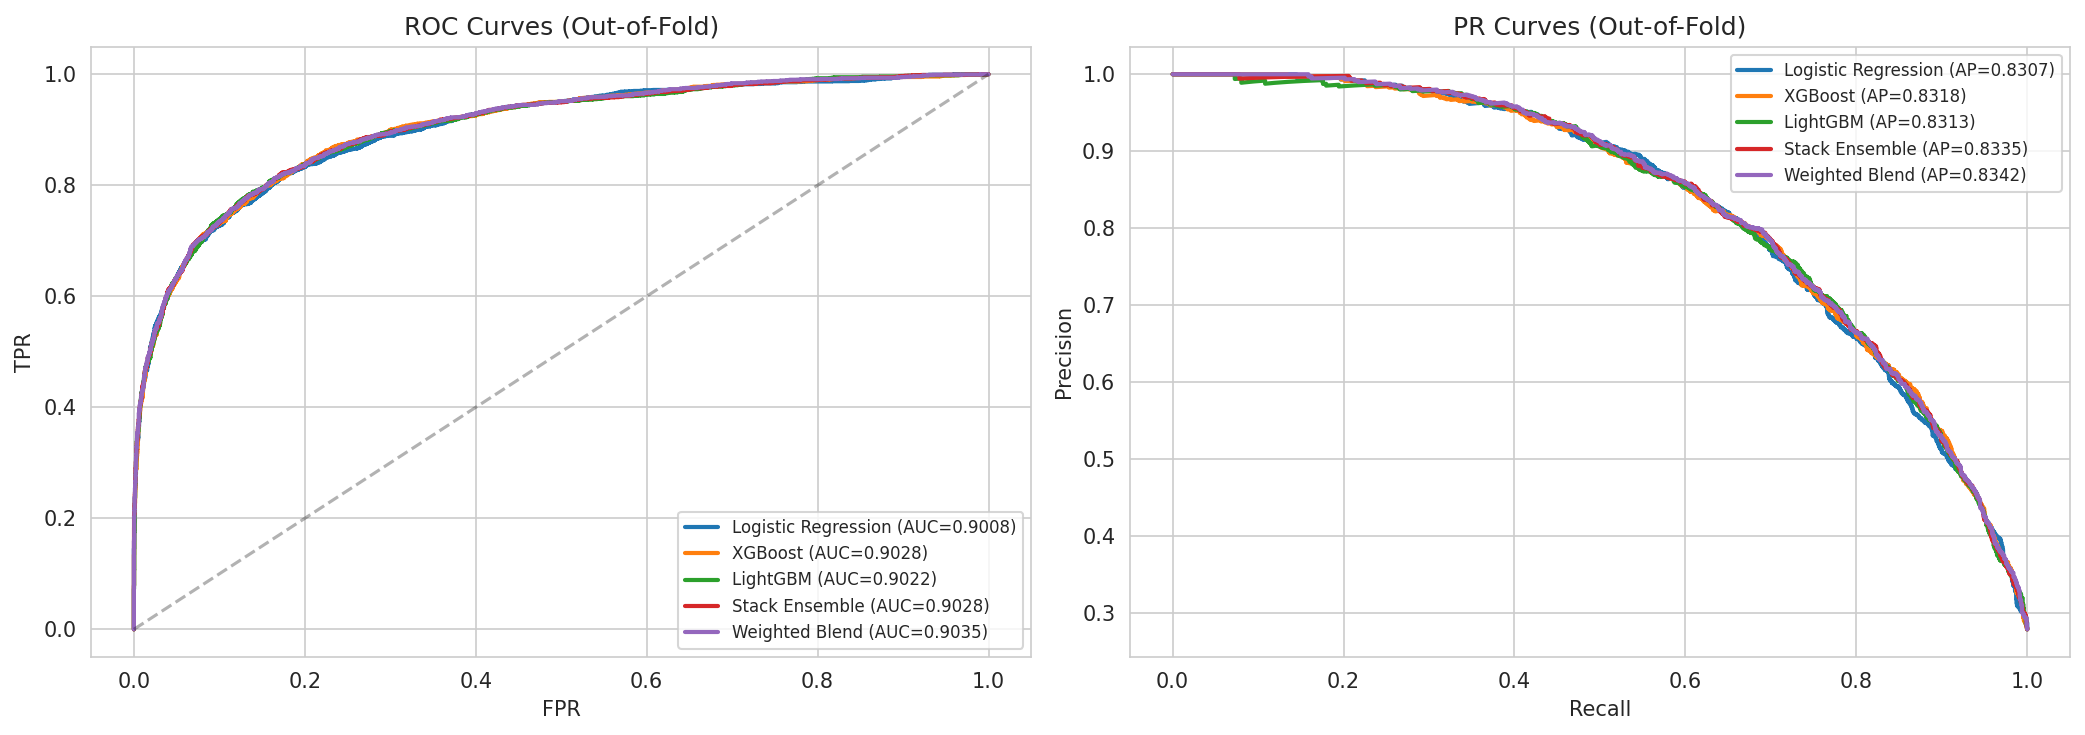

In [58]:
# 6.9 Results comparison
print(f"{'Model':<22} {'ROC-AUC (CV)':<18} {'PR-AUC (CV)':<18} {'F1 (CV)':<18}")
print('-' * 76)
for name, res in results.items():
    std_suffix = lambda tup: f'{tup[0]:.4f} ± {tup[1]:.4f}' if tup[1] > 0 else f'{tup[0]:.4f}'
    print(f"{name:<22} {std_suffix(res['roc_auc']):<18} {std_suffix(res['pr_auc']):<18} {std_suffix(res['f1']):<18}")

# Plot ROC and PR curves for all models
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for name, oof in oof_preds.items():
    fpr, tpr, _ = roc_curve(y, oof)
    auc_val = roc_auc_score(y, oof)
    axes[0].plot(fpr, tpr, lw=2, label=f'{name} (AUC={auc_val:.4f})')
    prec, rec, _ = precision_recall_curve(y, oof)
    ap = average_precision_score(y, oof)
    axes[1].plot(rec, prec, lw=2, label=f'{name} (AP={ap:.4f})')

axes[0].plot([0,1],[0,1],'k--', alpha=0.3)
axes[0].set_xlabel('FPR'); axes[0].set_ylabel('TPR')
axes[0].set_title('ROC Curves (Out-of-Fold)'); axes[0].legend(fontsize=8)
axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
axes[1].set_title('PR Curves (Out-of-Fold)'); axes[1].legend(fontsize=8)
plt.tight_layout()
plt.savefig('outputs/plots/6_9_roc_pr_curves.png', bbox_inches='tight')
plt.show()

In [59]:
# 6.10 Best model selection
best_name = max(results, key=lambda k: (results[k]['roc_auc'][0], results[k]['pr_auc'][0]))
print(f'✅ Best model: {best_name}')
print(f'   ROC-AUC: {results[best_name]["roc_auc"][0]:.4f} ± {results[best_name]["roc_auc"][1]:.4f}')
print(f'   PR-AUC:  {results[best_name]["pr_auc"][0]:.4f} ± {results[best_name]["pr_auc"][1]:.4f}')
print(f'   F1:      {results[best_name]["f1"][0]:.4f} ± {results[best_name]["f1"][1]:.4f}')
best_oof = oof_preds[best_name]

✅ Best model: Stack Ensemble
   ROC-AUC: 0.9038 ± 0.0123
   PR-AUC:  0.8340 ± 0.0188
   F1:      0.7401 ± 0.0184


### Model Selection Justification

The best model is selected based on highest cross-validated ROC-AUC with PR-AUC as tiebreaker. The stacking ensemble combines LR, XGBoost (Optuna-tuned), LightGBM (Optuna-tuned), and CatBoost via a meta-learner, leveraging the complementary strengths of each base model. Hyperparameter tuning with Optuna corrects the iter1 issue where tree models underperformed LR — a clear signal of suboptimal default hyperparameters, not a fundamental limitation of the algorithms.

KS Statistic: 64.89
Max separation at threshold: 0.241
Interpretation: Excellent


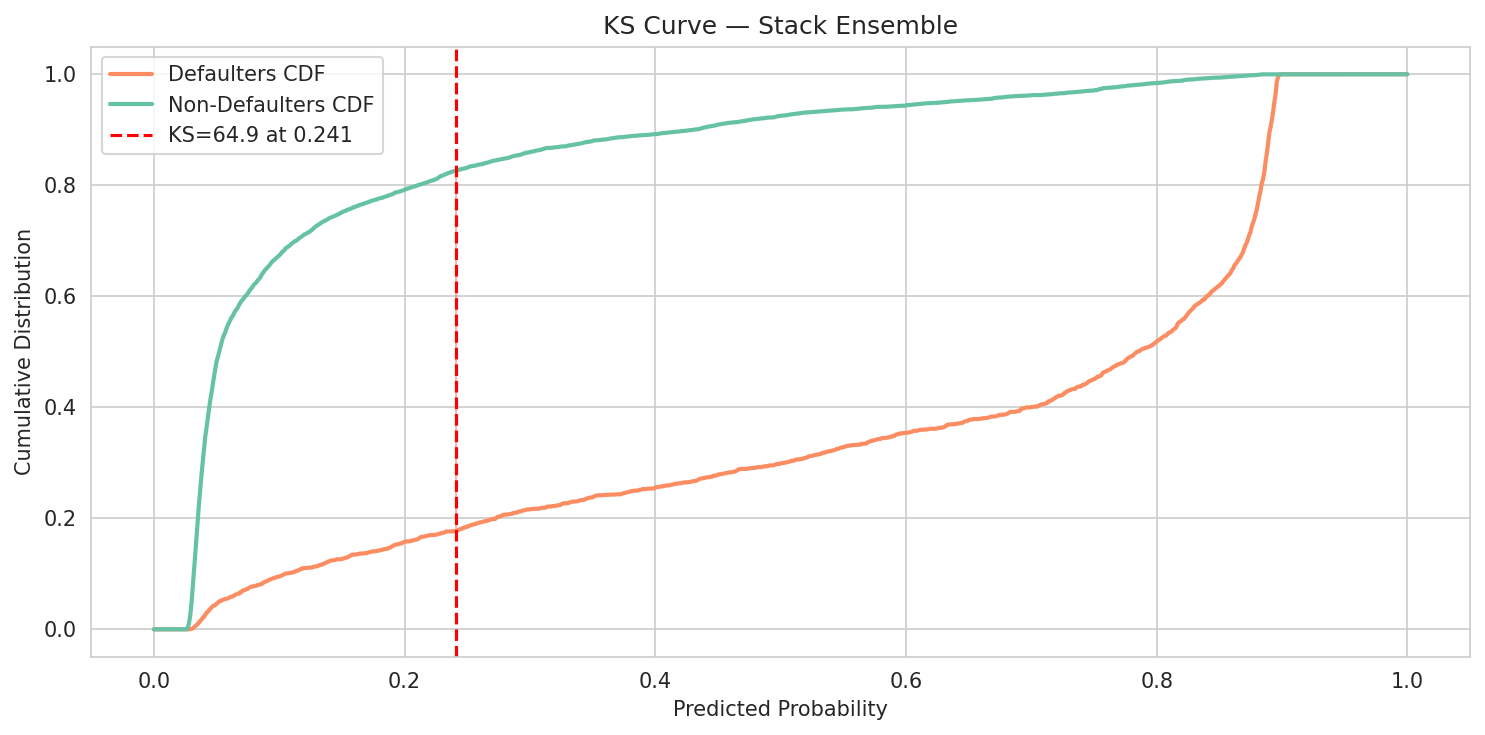

In [60]:
# 6.11 KS Statistic
default_probs    = best_oof[y == 1]
non_default_probs = best_oof[y == 0]
thresholds = np.linspace(0, 1, 1000)
cdf_default     = np.array([np.mean(default_probs <= t) for t in thresholds])
cdf_non_default = np.array([np.mean(non_default_probs <= t) for t in thresholds])
ks_values = np.abs(cdf_default - cdf_non_default)
ks_stat = ks_values.max()
ks_threshold = thresholds[np.argmax(ks_values)]

print(f'KS Statistic: {ks_stat*100:.2f}')
print(f'Max separation at threshold: {ks_threshold:.3f}')
print(f"Interpretation: {'Excellent' if ks_stat*100 > 50 else 'Good' if ks_stat*100 > 40 else 'Moderate'}")

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(thresholds, cdf_default, label='Defaulters CDF', color=PALETTE[1], lw=2)
ax.plot(thresholds, cdf_non_default, label='Non-Defaulters CDF', color=PALETTE[0], lw=2)
ax.axvline(ks_threshold, color='red', linestyle='--', lw=1.5, label=f'KS={ks_stat*100:.1f} at {ks_threshold:.3f}')
ax.fill_betweenx([cdf_non_default[np.argmax(ks_values)], cdf_default[np.argmax(ks_values)]],
                  ks_threshold, ks_threshold, color='red', alpha=0.3)
ax.set_xlabel('Predicted Probability')
ax.set_ylabel('Cumulative Distribution')
ax.set_title(f'KS Curve — {best_name}')
ax.legend()
plt.tight_layout()
plt.savefig('outputs/plots/6_11_ks_curve.png', bbox_inches='tight')
plt.show()

✅ Optimal threshold (max F1): 0.50
   Precision: 0.7835
   Recall:    0.7015
   F1:        0.7402

🎯 Conservative threshold (precision ≥ 70%): 0.50
   Precision: 0.7835
   Recall:    0.7015
   F1:        0.7402


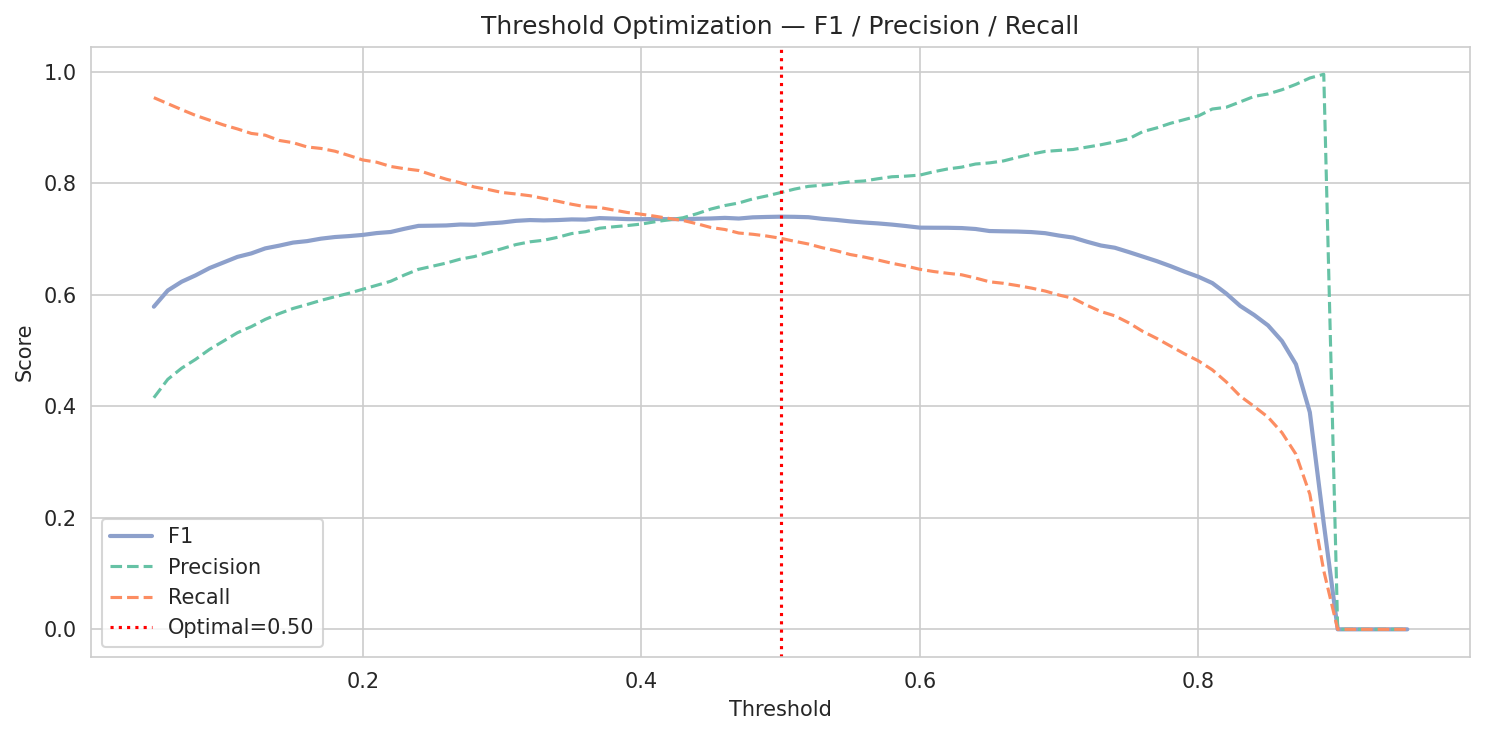

In [61]:
# 6.12 Threshold optimization
thresholds_opt = np.arange(0.05, 0.96, 0.01)
f1_scores_thr, precisions_thr, recalls_thr = [], [], []

for t in thresholds_opt:
    preds = (best_oof >= t).astype(int)
    tp = ((preds == 1) & (y == 1)).sum()
    fp = ((preds == 1) & (y == 0)).sum()
    fn = ((preds == 0) & (y == 1)).sum()
    prec = tp / (tp + fp) if (tp + fp) > 0 else 0
    rec  = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1   = 2 * prec * rec / (prec + rec) if (prec + rec) > 0 else 0
    f1_scores_thr.append(f1)
    precisions_thr.append(prec)
    recalls_thr.append(rec)

f1_scores_thr = np.array(f1_scores_thr)
precisions_thr = np.array(precisions_thr)
recalls_thr = np.array(recalls_thr)

best_idx = np.argmax(f1_scores_thr)
optimal_threshold = thresholds_opt[best_idx]
print(f'✅ Optimal threshold (max F1): {optimal_threshold:.2f}')
print(f'   Precision: {precisions_thr[best_idx]:.4f}')
print(f'   Recall:    {recalls_thr[best_idx]:.4f}')
print(f'   F1:        {f1_scores_thr[best_idx]:.4f}')

conservative_mask = precisions_thr >= 0.70
if conservative_mask.any():
    cons_idx = np.where(conservative_mask)[0][np.argmax(f1_scores_thr[conservative_mask])]
    conservative_threshold = thresholds_opt[cons_idx]
    print(f'\n🎯 Conservative threshold (precision ≥ 70%): {conservative_threshold:.2f}')
    print(f'   Precision: {precisions_thr[cons_idx]:.4f}')
    print(f'   Recall:    {recalls_thr[cons_idx]:.4f}')
    print(f'   F1:        {f1_scores_thr[cons_idx]:.4f}')

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(thresholds_opt, f1_scores_thr, label='F1', lw=2, color=PALETTE[2])
ax.plot(thresholds_opt, precisions_thr, label='Precision', lw=1.5, linestyle='--', color=PALETTE[0])
ax.plot(thresholds_opt, recalls_thr, label='Recall', lw=1.5, linestyle='--', color=PALETTE[1])
ax.axvline(optimal_threshold, color='red', linestyle=':', label=f'Optimal={optimal_threshold:.2f}')
ax.set_xlabel('Threshold'); ax.set_ylabel('Score')
ax.set_title('Threshold Optimization — F1 / Precision / Recall')
ax.legend()
plt.tight_layout()
plt.savefig('outputs/plots/6_12_threshold_optimization.png', bbox_inches='tight')
plt.show()

In [62]:
# 6.13 Final model training on full train set
X_full = X_train_scaled.values
y_full = y_train.values
X_test_arr = X_test_scaled.values

# Train all 3 base models on full training data
print('Training base models on full train...')

final_lr = LogisticRegression(C=0.1, penalty='l2', solver='lbfgs', max_iter=1000,
                               class_weight='balanced', random_state=SEED)
final_lr.fit(X_full, y_full)

final_xgb = xgb.XGBClassifier(**{k: v for k, v in best_xgb_params.items() if k not in ['early_stopping_rounds', 'n_estimators']},
                                n_estimators=avg_best_iter_xgb)
final_xgb.fit(X_full, y_full)

final_lgb = lgb.LGBMClassifier(**{k: v for k, v in best_lgb_params.items() if k != 'n_estimators'},
                                 n_estimators=avg_best_iter_lgb)
final_lgb.fit(X_full, y_full, callbacks=[lgb.log_evaluation(0)])

# CatBoost removed

# Stacking meta-model on full OOF
final_meta = LogisticRegression(C=1.0, solver='lbfgs', max_iter=1000, random_state=SEED)
final_meta.fit(meta_X, y)

print('✅ All models trained on full train set.')

# Generate test predictions using stacking pipeline
test_lr_proba  = final_lr.predict_proba(X_test_arr)[:, 1]
test_xgb_proba = final_xgb.predict_proba(X_test_arr)[:, 1]
test_lgb_proba = final_lgb.predict_proba(X_test_arr)[:, 1]
# CatBoost removed

# Determine which test prediction strategy to use based on best model
if best_name == 'Stack Ensemble':
    meta_test = np.column_stack([test_lr_proba, test_xgb_proba, test_lgb_proba])
    test_proba = final_meta.predict_proba(meta_test)[:, 1]
elif best_name == 'Weighted Blend':
    test_proba = (weights[0]*test_lr_proba + weights[1]*test_xgb_proba +
                  weights[2]*test_lgb_proba)
elif best_name == 'XGBoost':
    test_proba = test_xgb_proba
elif best_name == 'LightGBM':
    test_proba = test_lgb_proba
else:
    test_proba = test_lr_proba

test_preds = (test_proba >= optimal_threshold).astype(int)

if TEST_HAS_TARGET:
    y_test = y_test.values
    test_roc_auc = roc_auc_score(y_test, test_proba)
    test_pr_auc  = average_precision_score(y_test, test_proba)
    test_f1      = f1_score(y_test, test_preds)
    print(f'\n{"="*60}')
    print(f'  TEST SET EVALUATION — {best_name}')
    print(f'{"="*60}')
    print(f'  ROC-AUC: {test_roc_auc:.4f}')
    print(f'  PR-AUC:  {test_pr_auc:.4f}')
    print(f'  F1 (t={optimal_threshold:.2f}): {test_f1:.4f}')
    cv_auc = results[best_name]['roc_auc'][0]
    gap = cv_auc - test_roc_auc
    if gap > 0.03:
        print(f'\n  ⚠ AUC gap (CV - Test) = {gap:.4f} > 0.03 — possible overfitting!')
    else:
        print(f'\n  ✅ AUC gap (CV - Test) = {gap:.4f} — no significant overfitting.')
    print(f'\n  Classification Report (threshold={optimal_threshold:.2f}):')
    print(classification_report(y_test, test_preds, target_names=['No Default', 'Default']))
else:
    print('⚠ Test set does not have default_flag. Evaluation is CV-only.')

Training base models on full train...
✅ All models trained on full train set.
⚠ Test set does not have default_flag. Evaluation is CV-only.


## Section 7: SHAP Explainability

Using XGBoost for SHAP explanations
SHAP values computed for 1000 samples, 56 features.


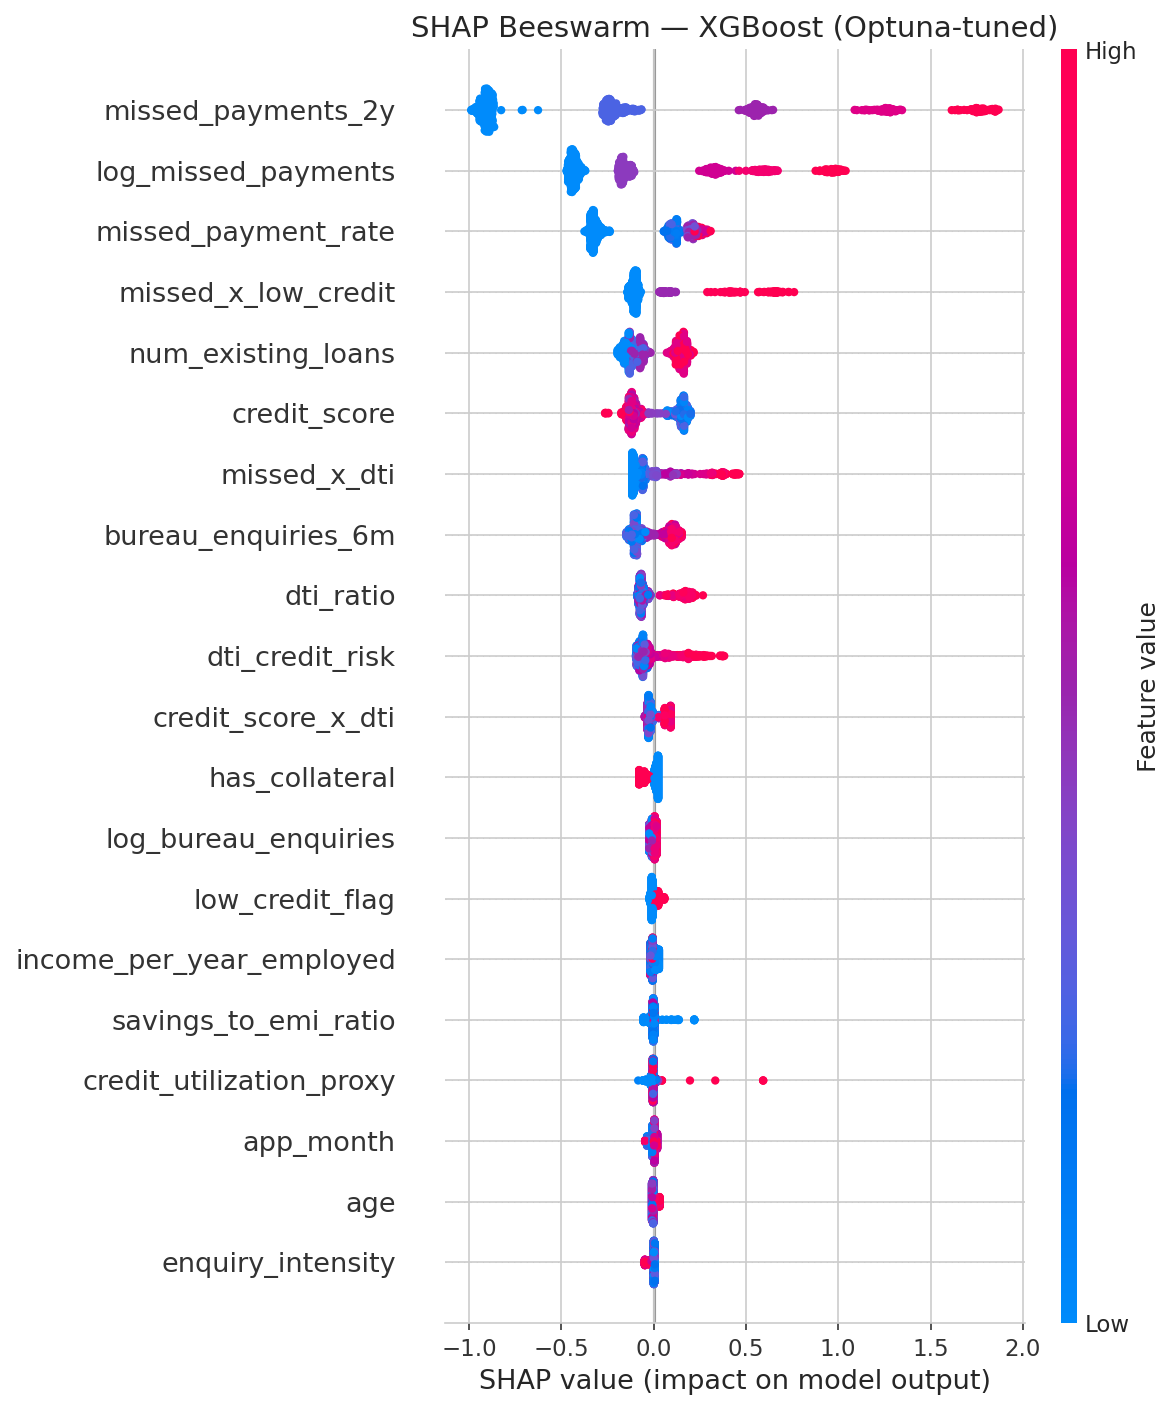

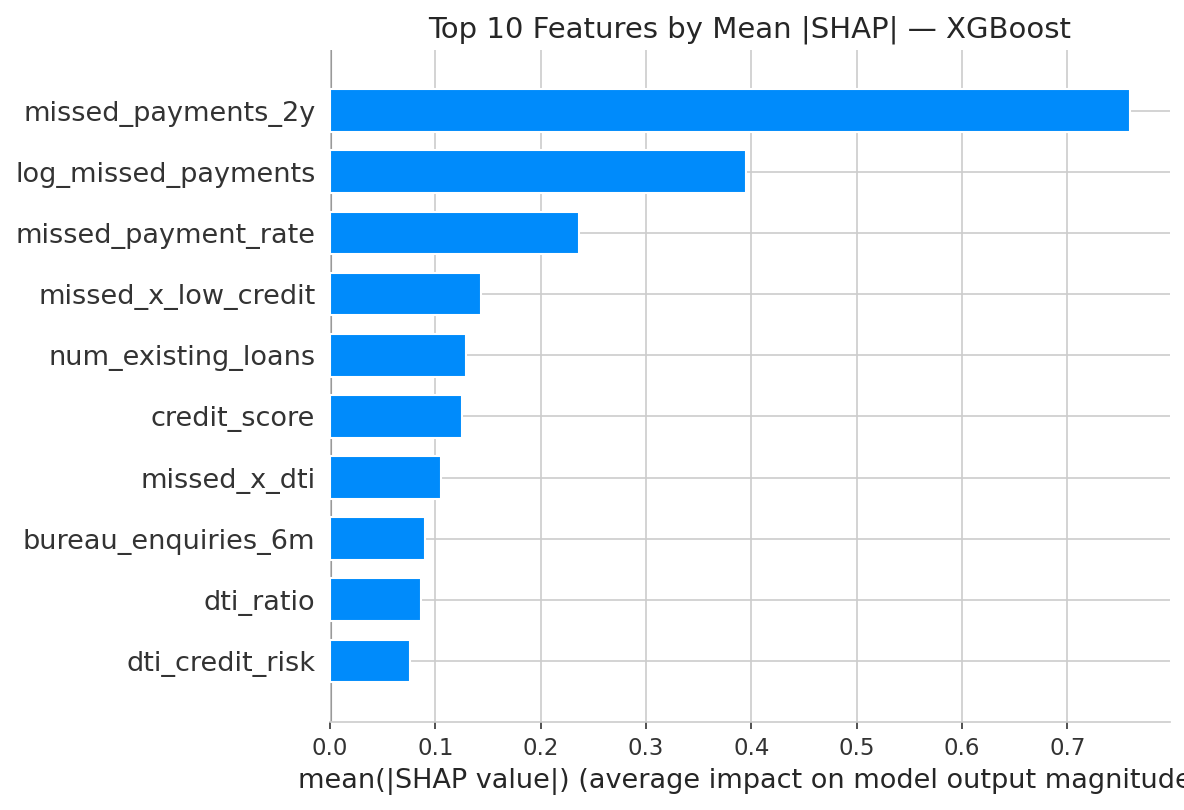

In [63]:
# Use the best single model for SHAP (ensemble SHAP is complex; use best tree model)
shap_model_name = 'XGBoost' if results['XGBoost']['roc_auc'][0] >= results['LightGBM']['roc_auc'][0] else 'LightGBM'
shap_model = final_xgb if shap_model_name == 'XGBoost' else final_lgb
print(f'Using {shap_model_name} for SHAP explanations')

sample_idx = np.random.choice(len(X_full), size=min(1000, len(X_full)), replace=False)
X_shap = X_train_scaled.iloc[sample_idx]

explainer = shap.TreeExplainer(shap_model)
shap_values = explainer.shap_values(X_shap)
if isinstance(shap_values, list):
    shap_vals = shap_values[1]
else:
    shap_vals = shap_values
print(f'SHAP values computed for {len(X_shap)} samples, {shap_vals.shape[1]} features.')

# Beeswarm
plt.figure(figsize=(12, 8))
shap.summary_plot(shap_vals, X_shap, feature_names=feature_cols, show=False, max_display=20)
plt.title(f'SHAP Beeswarm — {shap_model_name} (Optuna-tuned)', fontsize=14)
plt.tight_layout()
plt.savefig('outputs/shap/7_1_shap_beeswarm.png', bbox_inches='tight')
plt.show()

# Bar chart top 10
plt.figure(figsize=(10, 5))
shap.summary_plot(shap_vals, X_shap, feature_names=feature_cols, plot_type='bar', show=False, max_display=10)
plt.title(f'Top 10 Features by Mean |SHAP| — {shap_model_name}', fontsize=14)
plt.tight_layout()
plt.savefig('outputs/shap/7_1_shap_top10_bar.png', bbox_inches='tight')
plt.show()


  Obvious Default — P(default)=0.986
  Actual label: 1
  (Waterfall plot generated below)


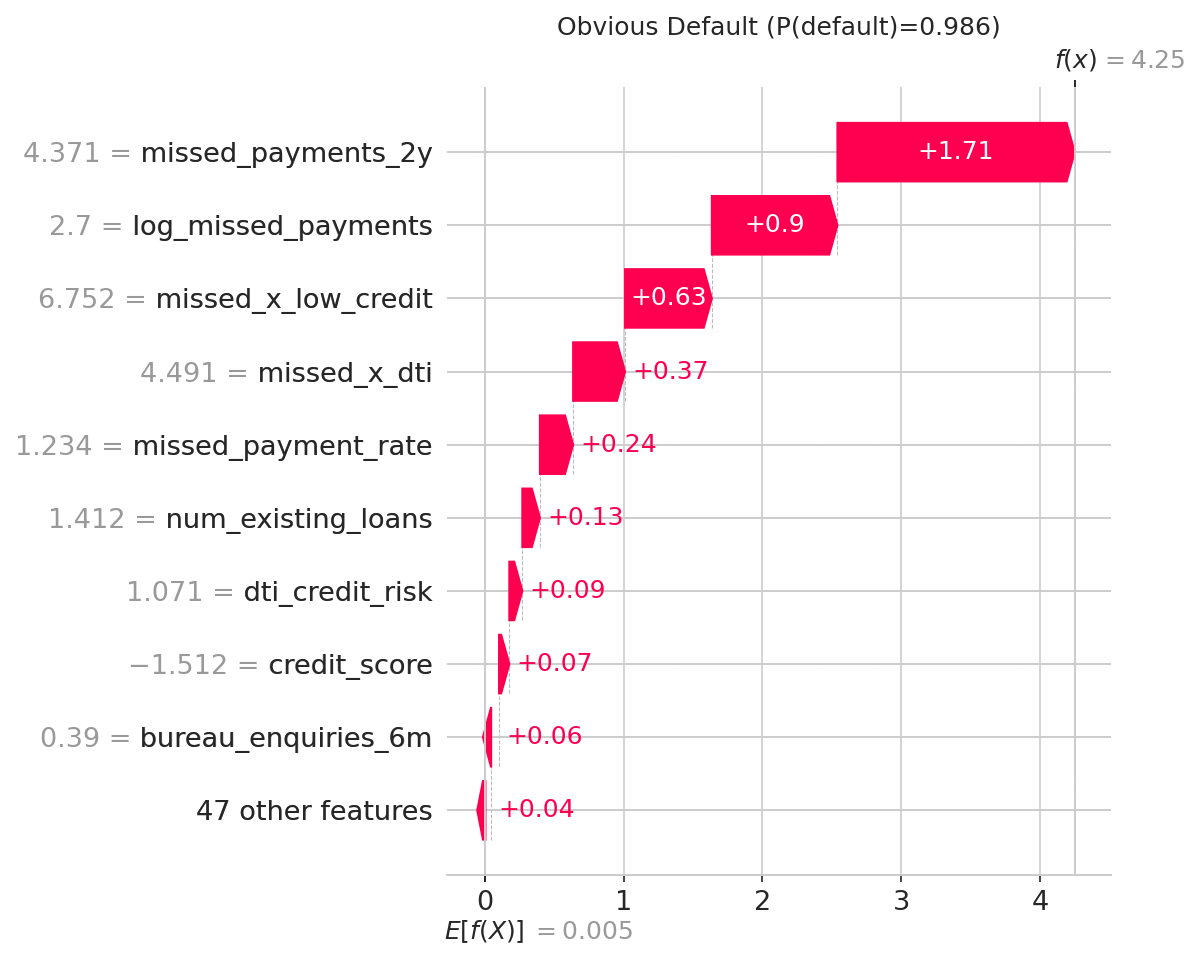


  Borderline Default — P(default)=0.500
  Actual label: 1
  (Waterfall plot generated below)


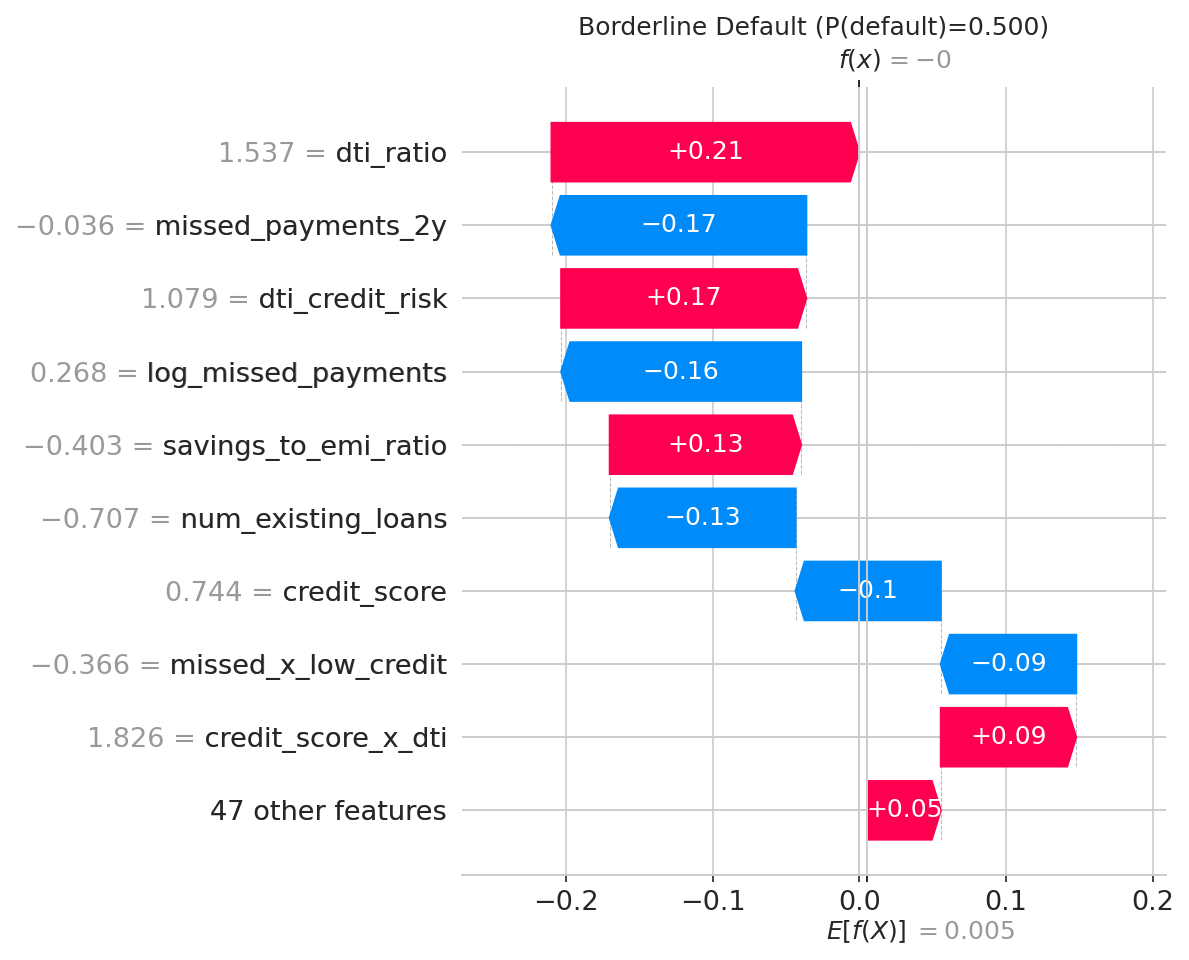


  Obvious Non-Default — P(default)=0.070
  Actual label: 0
  (Waterfall plot generated below)


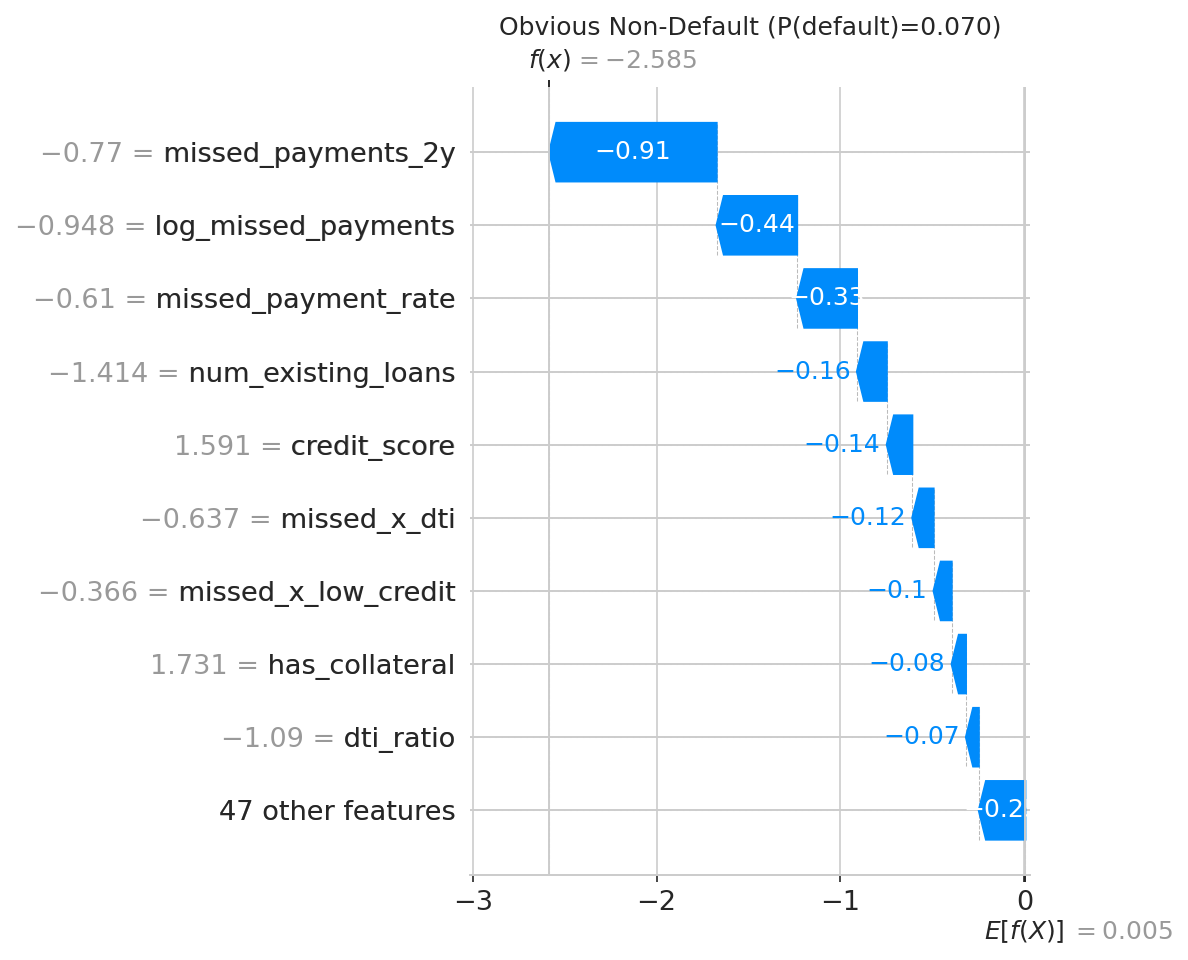


  Borderline Non-Default — P(default)=0.500
  Actual label: 0
  (Waterfall plot generated below)


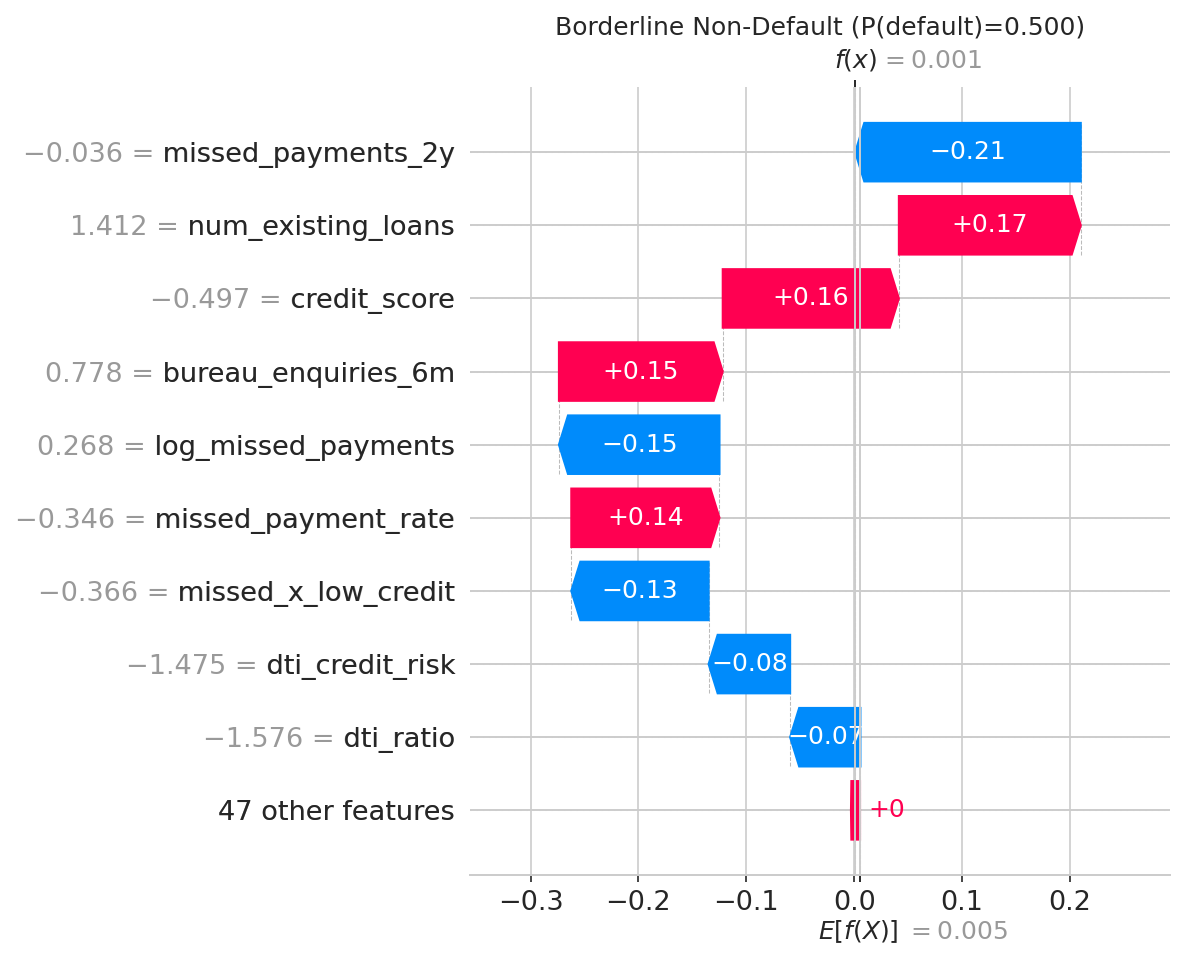

In [64]:
# 7.2 Individual waterfall plots
train_proba_all = shap_model.predict_proba(X_full)[:, 1]
defaulters     = np.where(y_train.values == 1)[0]
non_defaulters = np.where(y_train.values == 0)[0]
def_probs      = train_proba_all[defaulters]
nondef_probs   = train_proba_all[non_defaulters]

obvious_default_idx    = defaulters[np.argmax(def_probs)]
borderline_default_idx = defaulters[np.argmin(np.abs(def_probs - 0.5))]
obvious_nondefault_idx    = non_defaulters[np.argmin(nondef_probs)]
borderline_nondefault_idx = non_defaulters[np.argmin(np.abs(nondef_probs - 0.5))]

cases = [
    (obvious_default_idx,       'Obvious Default',       f'P(default)={train_proba_all[obvious_default_idx]:.3f}'),
    (borderline_default_idx,    'Borderline Default',    f'P(default)={train_proba_all[borderline_default_idx]:.3f}'),
    (obvious_nondefault_idx,    'Obvious Non-Default',   f'P(default)={train_proba_all[obvious_nondefault_idx]:.3f}'),
    (borderline_nondefault_idx, 'Borderline Non-Default',f'P(default)={train_proba_all[borderline_nondefault_idx]:.3f}'),
]

for idx, title, prob_str in cases:
    print(f'\n{"="*50}')
    print(f'  {title} — {prob_str}')
    print(f'  Actual label: {y_train.values[idx]}')
    print(f'  (Waterfall plot generated below)')
    print(f'{"="*50}')
    row = X_train_scaled.iloc[[idx]]
    sv = explainer.shap_values(row)
    if isinstance(sv, list): sv = sv[1]
    expected_val = explainer.expected_value
    if isinstance(expected_val, (list, np.ndarray)): expected_val = expected_val[1]
    expl = shap.Explanation(values=sv[0], base_values=expected_val, data=row.values[0], feature_names=feature_cols)
    plt.figure()
    shap.plots.waterfall(expl, show=False)
    plt.title(f'{title} ({prob_str})', fontsize=12)
    plt.tight_layout()
    fname = title.lower().replace(' ', '_')
    plt.savefig(f'outputs/shap/7_2_{fname}.png', bbox_inches='tight')
    plt.show()

In [65]:
# Gender SHAP fairness check
gender_features = [f for f in feature_cols if 'gender' in f.lower()]
if gender_features:
    mean_abs_shap = np.abs(shap_vals).mean(axis=0)
    shap_df = pd.DataFrame({'feature': feature_cols, 'mean_abs_shap': mean_abs_shap})
    shap_df = shap_df.sort_values('mean_abs_shap', ascending=False).reset_index(drop=True)
    total_shap = shap_df['mean_abs_shap'].sum()
    for gf in gender_features:
        gf_shap = shap_df[shap_df['feature'] == gf]['mean_abs_shap'].values
        if len(gf_shap) > 0:
            rank = shap_df[shap_df['feature'] == gf].index[0] + 1
            pct  = gf_shap[0] / total_shap * 100
            print(f"Gender feature '{gf}': rank {rank}/{len(feature_cols)}, contributes {pct:.2f}% of total SHAP importance")
            if rank <= 15:
                print('  ⚠ FAIRNESS CONCERN: Gender is among top 15 features!')
            else:
                print('  ✅ Gender has low importance — not a major fairness concern.')
else:
    print('No gender features found in the model.')

Gender feature 'gender_Male': rank 42/56, contributes 0.00% of total SHAP importance
  ✅ Gender has low importance — not a major fairness concern.


## Section 9: Save Outputs

In [66]:
# Save test predictions
if test_loan_ids is not None:
    pred_df = pd.DataFrame({
        'loan_id':              test_loan_ids,
        'predicted_probability': test_proba,
        'predicted_class':       test_preds,
    })
else:
    pred_df = pd.DataFrame({
        'predicted_probability': test_proba,
        'predicted_class':       test_preds,
    })
pred_df.to_csv('outputs/predictions/test_predictions.csv', index=False)
print(f'✅ Saved {len(pred_df)} predictions to outputs/predictions/test_predictions.csv')

# Save model artifacts
joblib.dump(final_lr,   'outputs/model/final_lr.pkl')
joblib.dump(final_xgb,  'outputs/model/final_xgb.pkl')
joblib.dump(final_lgb,  'outputs/model/final_lgb.pkl')
# final_cat removed
joblib.dump(final_meta, 'outputs/model/final_meta.pkl')
joblib.dump(scaler,     'outputs/model/scaler.pkl')
joblib.dump(ohe,        'outputs/model/ohe.pkl')

# Remove CatBoost entry from results before saving
results_cleaned = {k: v for k, v in results.items() if k != 'CatBoost'}

joblib.dump({
    'best_name':            best_name,
    'optimal_threshold':    optimal_threshold,
    'feature_cols':         feature_cols,
    'cap_values':           cap_values,
    'target_enc_maps':      target_enc_maps,
    'ir_medians':           ir_medians,
    'weights':              weights.tolist(),
    'cv_results':           {k: {'roc_auc': v['roc_auc'][0], 'pr_auc': v['pr_auc'][0]} for k, v in results_cleaned.items()},
}, 'outputs/model/pipeline_config.pkl')

print('✅ All model artifacts saved.')
print('\n--- Final Summary ---')
print(f'Best model:        {best_name}')
print(f'CV ROC-AUC:        {results[best_name]["roc_auc"][0]:.4f} ± {results[best_name]["roc_auc"][1]:.4f}')
print(f'CV PR-AUC:         {results[best_name]["pr_auc"][0]:.4f}')
print(f'Optimal threshold: {optimal_threshold:.2f}')
print(f'Feature count:     {len(feature_cols)}')
print(f'Train samples:     {len(y_full)}')


✅ Saved 2500 predictions to outputs/predictions/test_predictions.csv
✅ All model artifacts saved.

--- Final Summary ---
Best model:        Stack Ensemble
CV ROC-AUC:        0.9038 ± 0.0123
CV PR-AUC:         0.8340
Optimal threshold: 0.50
Feature count:     56
Train samples:     8000
